# 01 — EDA: рынок долгосрочной аренды СПб
Снимок ЦИАН от 2026-07-02, после чистки (`src/cleaning/clean.py`).
Цель: понять распределение цен, ключевые зависимости и зафиксировать находки для модели.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
C = '#2b6cb0'

df = pd.read_parquet('../data/processed/listings.parquet')
spb = df[df.is_lenobl == 0]
print(f'всего: {len(df)}, СПб: {len(spb)}, Ленобласть: {len(df) - len(spb)}')
df.head(3)

всего: 11525, СПб: 9278, Ленобласть: 2247


,offer_id,snapshot_date,price,deposit,client_fee_pct,agent_fee_pct,utilities_included,rooms,flat_type,is_apartments,...,published_ts,photos_count,region,url,rooms_n,is_studio,is_lenobl,price_per_m2,is_suspicious_cheap,n_clones
0,330969414,2026-07-02,28000,10000.0,0.0,0.0,0.0,3.0,rooms,0.0,...,1781716867,12,4588,https://spb.cian.ru/rent/flat/330969414/?mlSea...,3.0,0,1,500.000000,0,1
1,330900554,2026-07-02,15000,NaN,70.0,0.0,0.0,1.0,rooms,0.0,...,1782969845,14,4588,https://spb.cian.ru/rent/flat/330900554/?mlSea...,1.0,0,1,468.750000,0,1
2,329227323,2026-07-02,45000,20.0,100.0,50.0,0.0,3.0,rooms,NaN,...,1782906063,7,4588,https://spb.cian.ru/rent/flat/329227323/?mlSea...,3.0,0,1,818.181818,0,1


## Потери на чистке
Полный отчёт: `data/processed/cleaning_report.md`.

In [2]:
from pathlib import Path
print(Path('../data/processed/cleaning_report.md').read_text())

# Отчёт чистки данных

Снимок: 2026-07-02. Вход: 11978 объявлений, выход: 11525.

| Фильтр | Убрано строк | Осталось |
|---|---:|---:|
| исходно | — | 11978 |
| цена вне [8000, 350000] ₽/мес | 42 | 11936 |
| площадь вне [10.0, 200.0] м² | 34 | 11902 |
| нет координат | 0 | 11902 |
| цена/м² вне [300.0, 6000.0] ₽ | 12 | 11890 |
| не определить комнатность | 0 | 11890 |
| координаты вне агломерации СПб | 185 | 11705 |
| агентские клоны (одна квартира N раз) | 180 | 11525 |

Помечено флагом (не удалено):
- подозрительно дёшево (< 50% медианы района): 104
- апартаменты: 562
- Ленобласть: 2247



## Распределение цены — лог-нормальное (аргумент за log-target)

медиана: 43000 ₽, среднее: 55316 ₽ — правый хвост тянет среднее


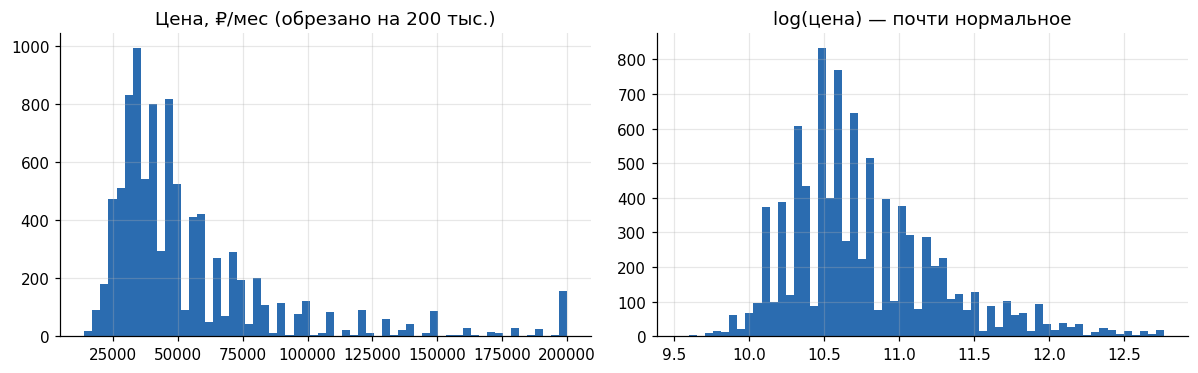

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
spb.price.clip(upper=200_000).hist(bins=60, ax=axes[0], color=C)
axes[0].set_title('Цена, ₽/мес (обрезано на 200 тыс.)')
np.log(spb.price).hist(bins=60, ax=axes[1], color=C)
axes[1].set_title('log(цена) — почти нормальное')
plt.tight_layout()
print('медиана: %d ₽, среднее: %d ₽ — правый хвост тянет среднее' % (spb.price.median(), spb.price.mean()))

## Цена за м² по районам — главный гео-сигнал

разброс по районам: 760–1895 ₽/м² — ×2.5


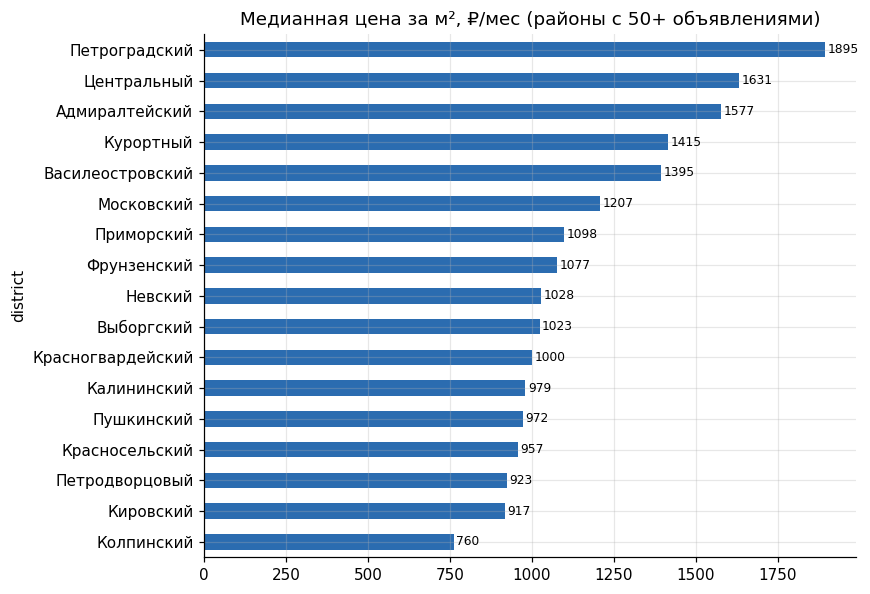

In [4]:
ppm = (spb.groupby('district').price_per_m2.agg(['median', 'count'])
       .query('count >= 50').sort_values('median'))
fig, ax = plt.subplots(figsize=(8, 5.5))
ppm['median'].plot.barh(ax=ax, color=C)
ax.set_title('Медианная цена за м², ₽/мес (районы с 50+ объявлениями)')
ax.set_xlabel('')
for i, (v, n) in enumerate(zip(ppm['median'], ppm['count'])):
    ax.text(v + 8, i, f'{v:.0f}', va='center', fontsize=8)
plt.tight_layout()
print('разброс по районам: %.0f–%.0f ₽/м² — ×%.1f' % (ppm['median'].min(), ppm['median'].max(), ppm['median'].max()/ppm['median'].min()))

## Цена по комнатности

студия: медиана   33,000 ₽  (n=2312)
     1: медиана   40,000 ₽  (n=3751)
     2: медиана   55,000 ₽  (n=2260)
     3: медиана   80,000 ₽  (n=805)
    4+: медиана  130,000 ₽  (n=150)


/sessions/vigilant-exciting-rubin/tmp/ipykernel_8/1216650537.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


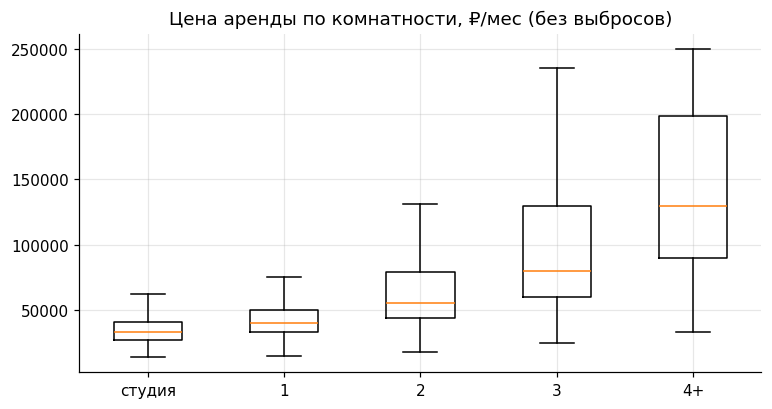

In [5]:
order = ['студия', '1', '2', '3', '4+']
spb2 = spb.assign(rooms_cat=np.select(
    [spb.is_studio == 1, spb.rooms_n == 1, spb.rooms_n == 2, spb.rooms_n == 3],
    ['студия', '1', '2', '3'], default='4+'))
data = [spb2[spb2.rooms_cat == c].price.clip(upper=250_000) for c in order]
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data, labels=order, showfliers=False)
ax.set_title('Цена аренды по комнатности, ₽/мес (без выбросов)')
for c in order:
    s = spb2[spb2.rooms_cat == c].price
    print(f'{c:>6}: медиана {s.median():>8,.0f} ₽  (n={len(s)})')

## Метро: каждая минута пешком стоит денег

премия «у метро» (≤5 мин vs 20–30): 15%


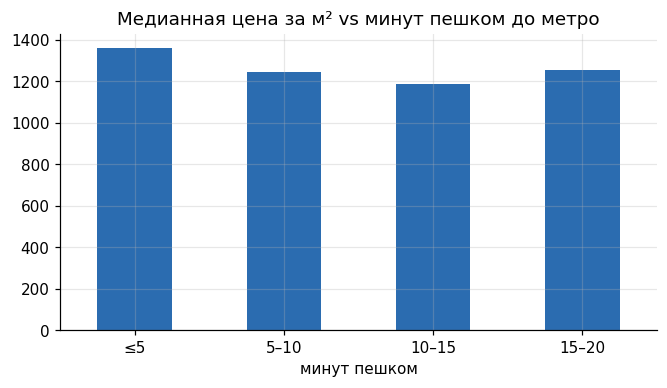

In [6]:
walk = spb[(spb.metro_transport == 'walk') & spb.metro_time_min.notna()].copy()
walk['bin'] = pd.cut(walk.metro_time_min, [0, 5, 10, 15, 20, 30, 60],
                     labels=['≤5', '5–10', '10–15', '15–20', '20–30', '30+'])
g = walk.groupby('bin', observed=True).price_per_m2.median()
fig, ax = plt.subplots(figsize=(7, 3.5))
g.plot.bar(ax=ax, color=C, rot=0)
ax.set_title('Медианная цена за м² vs минут пешком до метро')
ax.set_xlabel('минут пешком')
print('премия «у метро» (≤5 мин vs 20–30): %.0f%%' % ((g.iloc[0]/g.iloc[-2] - 1) * 100))

## Площадь vs цена

corr(log(area), log(price)) = 0.72


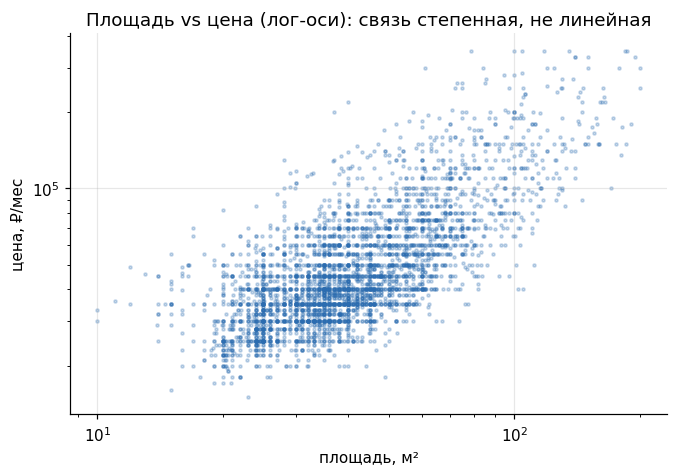

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
s = spb.sample(min(4000, len(spb)), random_state=42)
ax.scatter(s.total_area, s.price, s=4, alpha=0.25, color=C)
ax.set_yscale('log'); ax.set_xscale('log')
ax.set_xlabel('площадь, м²'); ax.set_ylabel('цена, ₽/мес')
ax.set_title('Площадь vs цена (лог-оси): связь степенная, не линейная')
corr = np.corrcoef(np.log(spb.total_area), np.log(spb.price))[0, 1]
print(f'corr(log(area), log(price)) = {corr:.2f}')

## Собственник vs агент

In [8]:
g = spb.groupby('is_by_homeowner').agg(
    n=('price', 'size'), медиана_цены=('price', 'median'),
    медиана_м2=('price_per_m2', 'median'))
g.index = ['агент', 'собственник']
print(g)
print()
lo = df[df.is_lenobl == 1]
print(f'Ленобласть: медиана {lo.price.median():,.0f} ₽ vs СПб {spb.price.median():,.0f} ₽ '
      f'(дисконт {(1 - lo.price.median()/spb.price.median())*100:.0f}%)')

                n  медиана_цены   медиана_м2
агент        4506       42000.0  1070.422535
собственник  3069       42000.0  1152.073733

Ленобласть: медиана 28,000 ₽ vs СПб 43,000 ₽ (дисконт 35%)


## Выводы для модели
1. **Log-target обязателен** — распределение цены лог-нормальное, хвост до 350 тыс.
2. **География — сигнал №1**: разброс медианной цены/м² между районами кратный; район + координаты + минуты до метро должны войти в модель.
3. **Комнатность нелинейна**: студия ≈ однушка по цене/м², дальше цена/м² падает, а цена растёт — подтверждает выбор деревьев над линейной моделью.
4. **Метро**: премия за ≤5 мин пешком заметна — расстояние до метро как непрерывный признак.
5. **Собственник vs агент** — различие в цене есть, флаг в модель.
6. **Ленобласть дешевле** — флаг `is_lenobl` обязателен, иначе модель размажет границу города.
7. Флаги `is_suspicious_cheap` (104 шт.) — кандидаты в скам, исключить из train, но прогнать через детектор переплаты как негативные примеры.